<a href="https://colab.research.google.com/github/Van004-ds/Van004-ds/blob/main/Credit_Card_Fraud_Detection_Rule_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Mini Project: Credit Card Fraud
Detection Rule Engine**

In [ ]:
print("Mini Project: Credit Card Fraud Detection Rule Engine")

Mini Project: Credit Card Fraud Detection Rule Engine


In [ ]:
transactions = [
    {"id": 1001, "amount": 1200, "country": "USA", "status": "success"},
    {"id": 1002, "amount": 8000, "country": "Russia", "status": "success"},
    {"id": 1003, "amount": 10, "country": "India", "status": "failed"},
    {"id": 1004, "amount": 50000, "country": "Nigeria", "status": "success"},
    {"id": 1005, "amount": 300, "country": "USA", "status": "failed"},
    {"id": 1006, "amount": 700, "country": "China", "status": "success"},
    {"id": 1007, "amount": 3000, "country": "India", "status": "failed"},
]


In [ ]:
from typing import Counter
blacklisted_countries = ["russia", "nigeria","Russia", "Nigeria"]
failed_count = 0
for tr in transactions :
  print(f"transactioin ID :{tr['id']} - ${tr['amount']} from {tr['country']}")
  if tr['amount'] > 10000:
    print(" suspecious activity deteted  <high value transaction>")
  if tr['country'] in blacklisted_countries:
    print(f" blacklistd country transactioni alter{ tr['country']}")

  if tr['status'] == "failed":
    failed_count+=1
    print(" transactioin attempt  failed logged ")

  if failed_count>=2:
    print("suspicious failed attempts , it is a risk")
    break


transactioin ID :1001 - $1200 from USA
transactioin ID :1002 - $8000 from Russia
 blacklistd country transactioni alterRussia
transactioin ID :1003 - $10 from India
 transactioin attempt  failed logged 
transactioin ID :1004 - $50000 from Nigeria
 suspecious activity deteted  <high value transaction>
 blacklistd country transactioni alterNigeria
transactioin ID :1005 - $300 from USA
 transactioin attempt  failed logged 
suspicious failed attempts , it is a risk


In [ ]:
# creating a csv file using pandas

In [ ]:
import pandas as pd

csv_data =  """id,amount,country,status
1001,1200,USA,success
1002,8000,Russia,success
1003,10,India,failed
1004,50000,Nigeria,success
1005,300,USA,failed
"""



with open("transactions.csv","w") as file :
  file.write(csv_data)

df = pd.read_csv("transactions.csv")
print(df)





     id  amount  country   status
0  1001    1200      USA  success
1  1002    8000   Russia  success
2  1003      10    India   failed
3  1004   50000  Nigeria  success
4  1005     300      USA   failed


In [ ]:
!pip install plotly

In [37]:
blacklist_countri = ["Russia", "Nigeria"]
df["is_flagged"] = (
    (df["amount"]> 10000)|(df['status']=='failed')|
    (df["country"].str.lower().isin(c.lower() for c in blacklist_countri))

)
print(df)

flagged_df = df[df["is_flagged"]== True]
print("\n")
print(flagged_df)





     id  amount  country   status  is_flagged
0  1001    1200      USA  success       False
1  1002    8000   Russia  success        True
2  1003      10    India   failed        True
3  1004   50000  Nigeria  success        True
4  1005     300      USA   failed        True


     id  amount  country   status  is_flagged
1  1002    8000   Russia  success        True
2  1003      10    India   failed        True
3  1004   50000  Nigeria  success        True
4  1005     300      USA   failed        True


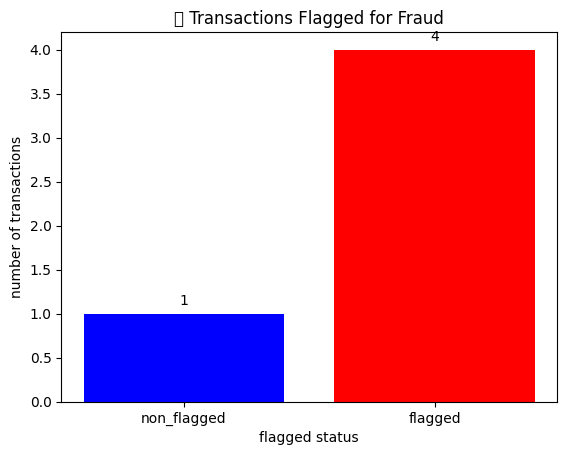

In [44]:
import matplotlib.pyplot as plt
flagged_count = df["is_flagged"].value_counts()
non_flagged = flagged_count.get(False,0)
flagged = flagged_count.get(True,0)
bars = plt.bar(["non_flagged", "flagged"],[non_flagged,flagged], color = ["blue","red"])
plt.title("🔍 Transactions Flagged for Fraud")
plt.xlabel("flagged status")
plt.ylabel("number of transactions")
for bar in bars :
  yvalue = bar.get_height()
  plt.text(bar.get_x()+ bar.get_width()/2, yvalue + 0.1 , int (yvalue), ha = "center")
plt.show()

In [45]:
print(flagged_count)

is_flagged
True     4
False    1
Name: count, dtype: int64
